# Intel SKU Demand Dataset - Exploratory Analysis

***NOTE:** SKU stands for Stock Keeping Unit*

## 1. Setup

The notebook locates the repository by searching upward for `data/Intel_SKU/raw`.

Expected raw files:

```text
data/Intel_SKU/raw/
├── Intel_actual_demand.csv
├── startend_date.csv
└── msom.2020.0933.csv
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]
    for path in candidates:
        if (path / "data" / "Intel_SKU" / "raw").exists():
            return path
    raise FileNotFoundError("Could not find repository root.")

ROOT = find_repo_root()
RAW_DIR = ROOT / "data" / "Intel_SKU" / "raw"

DEMAND_PATH = RAW_DIR / "Intel_actual_demand.csv"
LIFECYCLE_PATH = RAW_DIR / "startend_date.csv"
SOURCE_PATH = RAW_DIR / "msom.2020.0933.csv"

print("Repository root:", ROOT)
print("Raw directory:", RAW_DIR)
print("Demand file:", DEMAND_PATH)
print("Lifecycle file:", LIFECYCLE_PATH)
print("Original source file:", SOURCE_PATH)


Repository root: d:\SEM 7\Honours by Research\GitHub_Sundial\ColdStart_Sundial
Raw directory: d:\SEM 7\Honours by Research\GitHub_Sundial\ColdStart_Sundial\data\Intel_SKU\raw
Demand file: d:\SEM 7\Honours by Research\GitHub_Sundial\ColdStart_Sundial\data\Intel_SKU\raw\Intel_actual_demand.csv
Lifecycle file: d:\SEM 7\Honours by Research\GitHub_Sundial\ColdStart_Sundial\data\Intel_SKU\raw\startend_date.csv
Original source file: d:\SEM 7\Honours by Research\GitHub_Sundial\ColdStart_Sundial\data\Intel_SKU\raw\msom.2020.0933.csv


## 2. Load the raw files

In [2]:
demand_wide = pd.read_csv(DEMAND_PATH)
sku_metadata = pd.read_csv(LIFECYCLE_PATH)
source = pd.read_csv(SOURCE_PATH)

print("Demand data shape:", demand_wide.shape)
print("SKU metadata shape:", sku_metadata.shape)
print("Original source shape:", source.shape)

display(demand_wide.head())
display(sku_metadata.head())
display(source.head())


Demand data shape: (187, 87)
SKU metadata shape: (86, 3)
Original source shape: (26114, 8)


,Week,SKU.A.2,SKU.B.2,SKU.C.1,SKU.C.2,SKU.F.1,SKU.F.2,SKU.H.2,SKU.I.2,SKU.J.2,SKU.K.2,SKU.L.1,SKU.L.2,SKU.M.2,SKU.O.1,SKU.O.2,SKU.Q.2,SKU.S.2,SKU.B.1,SKU.E.2,SKU.G.2,SKU.H.1,SKU.K.1,SKU.N.2,SKU.Q.1,SKU.M.1,SKU.Q.3,SKU.C.3,SKU.F.3,SKU.H.3,SKU.K.3,SKU.O.3,SKU.B.3,SKU.G.3,SKU.L.3,SKU.N.3,SKU.A.3,SKU.E.3,SKU.I.3,SKU.S.3,SKU.U.3,SKU.T.3,SKU.J.3,SKU.B.4,SKU.O.4,SKU.Q.4,SKU.U.4,SKU.W.4,SKU.C.4,SKU.K.4,SKU.L.4,SKU.A.4,SKU.T.4,SKU.D.4,SKU.F.4,SKU.G.4,SKU.H.4,SKU.V.4,SKU.I.4,SKU.N.4,SKU.R.4,SKU.S.4,SKU.J.4,SKU.E.4,SKU.P.4,SKU.A.5,SKU.D.5,SKU.K.5,SKU.C.5,SKU.B.5,SKU.R.5,SKU.T.5,SKU.U.5,SKU.V.5,SKU.Y.5,SKU.X.5,SKU.L.5,SKU.Q.5,SKU.S.5,SKU.W.5,SKU.J.5,SKU.E.5,SKU.F.5,SKU.H.5,SKU.N.5,SKU.I.5,SKU.G.5
0,1,"28,025.000","118,312.000","55,542.000","161,943.000","31,625.000","120,064.000","150,956.000","47,929.000","12,897.000","144,905.000","3,423.000","66,880.000","42,993.000","4,140.000","126,115.000","95,222.000","83,759.000",557.000,"16,878.000","2,930.000","5,494.000","8,917.000","37,611.000","2,468.000","2,293.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"48,250.000","155,573.000","50,478.000","156,689.000","33,041.000","101,911.000","176,115.000","30,414.000","7,643.000","115,447.000","1,831.000","64,968.000","59,553.000","3,981.000","204,300.000","83,121.000","86,465.000","1,433.000","42,038.000","3,343.000","4,633.000","11,146.000","28,502.000","1,114.000","3,264.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,"40,128.000","242,675.000","44,427.000","203,344.000","20,143.000","117,198.000","166,719.000","37,419.000","3,821.000","121,497.000",239.000,"117,357.000","59,395.000","4,140.000","117,676.000","83,281.000","108,121.000",0.000,"62,419.000","3,981.000","4,332.000","5,414.000","17,038.000","4,140.000","1,449.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"48,966.000","222,930.000","18,790.000","228,025.000","25,795.000","96,656.000","144,428.000","41,721.000","2,548.000","114,968.000",239.000,"94,746.000","35,827.000","5,255.000","103,344.000","71,099.000","91,720.000",478.000,"14,013.000","4,776.000","4,140.000","6,369.000","22,611.000","1,672.000","3,025.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,"74,044.000","260,351.000","68,153.000","397,134.000","18,312.000","178,185.000","242,357.000","80,016.000","17,993.000","201,512.000","2,787.000","157,324.000","80,572.000","2,070.000","315,446.000","138,694.000","152,070.000",637.000,"67,834.000","8,121.000","1,066.000","7,006.000","36,705.000","4,379.000","12,420.000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,sku,start,end
0,SKU-A-2,1,110
1,SKU-B-2,1,110
2,SKU-C-1,1,45
3,SKU-C-2,1,116
4,SKU-F-1,1,45


,Distribution Center,Product Offering,Generation,SKU,ASP Group,Week,Forecasted Demand,Customer Orders
0,ALPHA,A,2,SKU-A-2,1,1,8949,11146
1,ALPHA,B,2,SKU-B-2,1,1,11146,3503
2,ALPHA,C,1,SKU-C-1,3,1,1274,5892
3,ALPHA,C,2,SKU-C-2,4,1,20717,3185
4,ALPHA,F,1,SKU-F-1,6,1,24522,6529


Here, sku_metadata shows how long data is available for each SKU and what the duration is (example: SKU-A-2 data is available from the 1st to the 110th week).

Source shows the demand information for one SKU at one particular week at one particular distribution center

In source, ASP_Group refers to the Average Selling Price Group for that product

## 3. Basic schema and dimensions

In [32]:
print("Demand columns:")
display(demand_wide.dtypes.to_frame("dtype"))

print("\nMetadata columns:")
display(sku_metadata.dtypes.to_frame("dtype"))

print("\nSource columns:")
display(source.dtypes.to_frame("dtype"))

print("\nDemand shape:", demand_wide.shape)
print("Number of demand-series columns:", demand_wide.shape[1] - 1)
print("Number of metadata rows:", len(sku_metadata))


Demand columns:


,dtype
Week,int64
SKU.A.2,float64
SKU.B.2,float64
SKU.C.1,float64
SKU.C.2,float64
SKU.F.1,float64
SKU.F.2,float64
SKU.H.2,float64
SKU.I.2,float64
SKU.J.2,float64



Metadata columns:


,dtype
sku,str
start,int64
end,int64



Source columns:


,dtype
Distribution Center,str
Product Offering,str
Generation,int64
SKU,str
ASP Group,int64
Week,int64
Forecasted Demand,int64
Customer Orders,int64



Demand shape: (187, 87)
Number of demand-series columns: 86
Number of metadata rows: 86


## Checking how many SKUs are present in each file


In [6]:
expected_demand_id = "Week"
expected_metadata_cols = {"sku", "start", "end"}
expected_source_cols = {
    "Distribution Center", "Product Offering", "Generation",
    "SKU", "ASP Group", "Week", "Forecasted Demand", "Customer Orders"
}

assert expected_demand_id in demand_wide.columns
assert expected_metadata_cols.issubset(sku_metadata.columns)
assert expected_source_cols.issubset(source.columns)

demand_skus = set(demand_wide.columns) - {expected_demand_id}
metadata_skus = set(sku_metadata["sku"].astype(str))
source_skus = set(source["SKU"].astype(str))

print("Demand SKUs:", len(demand_skus))
print("Metadata SKUs:", len(metadata_skus))
print("Source SKUs:", len(source_skus))


Demand SKUs: 86
Metadata SKUs: 86
Source SKUs: 86


# 4. Aggregate-Demand Consistency

In [39]:
# Compare aggregated Customer Orders against the existing demand file.

demand_long_check = demand_wide.melt(
    id_vars="Week",
    var_name="demand_sku",
    value_name="aggregated_customer_orders",
)

demand_long_check["sku"] = (
    demand_long_check["demand_sku"]
    .str.replace(".", "-", regex=False)
)

# Exclude missing cells outside the recorded demand observations.
demand_long_check = demand_long_check[
    demand_long_check["aggregated_customer_orders"].notna()
].copy()

source_aggregated = (
    source.groupby(["Week", "SKU"])["Customer Orders"]
    .sum()
    .reset_index(name="source_customer_orders")
    .rename(columns={"SKU": "sku"})
)

comparison = demand_long_check.merge(
    source_aggregated,
    on=["Week", "sku"],
    how="left",
    indicator=True,
)

print("Non-missing demand observations:", len(comparison))
print(
    "Observations with a source record:",
    int((comparison["_merge"] == "both").sum()),
)
print(
    "Observations without a source record:",
    int((comparison["_merge"] == "left_only").sum()),
)

# An absent source record is treated as zero for this comparison only.
comparison["source_customer_orders"] = (
    comparison["source_customer_orders"].fillna(0)
)

comparison["match"] = np.isclose(
    comparison["aggregated_customer_orders"],
    comparison["source_customer_orders"],
)

mismatches = comparison.loc[~comparison["match"]]

print("Mismatched observations:", len(mismatches))

if not mismatches.empty:
    display(mismatches.head(20))
else:
    print("All non-missing aggregate demand values match the source.")

Non-missing demand observations: 7721
Observations with a source record: 7421
Observations without a source record: 300
Mismatched observations: 0
All non-missing aggregate demand values match the source.


The comparison shows that all non-missing demand values in `Intel_actual_demand.csv` match the corresponding sums of `Customer Orders` in the original source dataset. In 300 cases, the aggregate demand is zero despite the absence of a corresponding SKU-week record in the source. Thus, the two datasets are numerically consistent under the assumption that an absent source record represents zero demand for that SKU-week.

## 5. SKU identifier consistency

In [7]:
# The files use different punctuation conventions for SKU identifiers.
# Inspect them before deciding how preprocessing should normalize them.

def canonical_sku_for_comparison(s):
    return (
        str(s).strip().upper()
        .replace("-", "")
        .replace(".", "")
        .replace("_", "")
        .replace(" ", "")
    )

demand_sku_sample = sorted(demand_skus)[:20]
metadata_sku_sample = sorted(metadata_skus)[:20]
source_sku_sample = sorted(source_skus)[:20]

print("Demand-file SKU examples:")
print(demand_sku_sample)

print("\nMetadata-file SKU examples:")
print(metadata_sku_sample)

print("\nSource-file SKU examples:")
print(source_sku_sample)


Demand-file SKU examples:
['SKU.A.2', 'SKU.A.3', 'SKU.A.4', 'SKU.A.5', 'SKU.B.1', 'SKU.B.2', 'SKU.B.3', 'SKU.B.4', 'SKU.B.5', 'SKU.C.1', 'SKU.C.2', 'SKU.C.3', 'SKU.C.4', 'SKU.C.5', 'SKU.D.4', 'SKU.D.5', 'SKU.E.2', 'SKU.E.3', 'SKU.E.4', 'SKU.E.5']

Metadata-file SKU examples:
['SKU-A-2', 'SKU-A-3', 'SKU-A-4', 'SKU-A-5', 'SKU-B-1', 'SKU-B-2', 'SKU-B-3', 'SKU-B-4', 'SKU-B-5', 'SKU-C-1', 'SKU-C-2', 'SKU-C-3', 'SKU-C-4', 'SKU-C-5', 'SKU-D-4', 'SKU-D-5', 'SKU-E-2', 'SKU-E-3', 'SKU-E-4', 'SKU-E-5']

Source-file SKU examples:
['SKU-A-2', 'SKU-A-3', 'SKU-A-4', 'SKU-A-5', 'SKU-B-1', 'SKU-B-2', 'SKU-B-3', 'SKU-B-4', 'SKU-B-5', 'SKU-C-1', 'SKU-C-2', 'SKU-C-3', 'SKU-C-4', 'SKU-C-5', 'SKU-D-4', 'SKU-D-5', 'SKU-E-2', 'SKU-E-3', 'SKU-E-4', 'SKU-E-5']


In [8]:
demand_canonical = {canonical_sku_for_comparison(s): s for s in demand_skus}
metadata_canonical = {canonical_sku_for_comparison(s): s for s in metadata_skus}
source_canonical = {canonical_sku_for_comparison(s): s for s in source_skus}

print("Demand-only canonical IDs:", len(set(demand_canonical) - set(metadata_canonical)))
print("Metadata-only canonical IDs:", len(set(metadata_canonical) - set(demand_canonical)))
print("Demand/source canonical mismatches:", len(set(demand_canonical) ^ set(source_canonical)))


Demand-only canonical IDs: 0
Metadata-only canonical IDs: 0
Demand/source canonical mismatches: 0


## 6. Original source: product attributes

The original source contains distribution-center-level records with:

- `Product Offering`
- `Generation`
- `ASP Group`
- `Forecasted Demand`
- `Customer Orders`

The first three are static product attributes and are the important addition for the cold-start metadata representation.

In [9]:
print("Original source shape:", source.shape)
print("Distribution centers:", source["Distribution Center"].nunique())
print("Product offerings:", source["Product Offering"].nunique())
print("Generations:", source["Generation"].nunique())
print("ASP groups:", source["ASP Group"].nunique())

display(source.head(10))


Original source shape: (26114, 8)
Distribution centers: 5
Product offerings: 25
Generations: 5
ASP groups: 21


,Distribution Center,Product Offering,Generation,SKU,ASP Group,Week,Forecasted Demand,Customer Orders
0,ALPHA,A,2,SKU-A-2,1,1,8949,11146
1,ALPHA,B,2,SKU-B-2,1,1,11146,3503
2,ALPHA,C,1,SKU-C-1,3,1,1274,5892
3,ALPHA,C,2,SKU-C-2,4,1,20717,3185
4,ALPHA,F,1,SKU-F-1,6,1,24522,6529
5,ALPHA,F,2,SKU-F-2,7,1,7245,6210
6,ALPHA,H,2,SKU-H-2,9,1,7962,8599
7,ALPHA,I,2,SKU-I-2,10,1,637,159
8,ALPHA,J,2,SKU-J-2,11,1,111,318
9,ALPHA,K,2,SKU-K-2,11,1,3185,6688


### Static attribute consistency within each SKU

In [10]:
attribute_cols = ["Product Offering", "Generation", "ASP Group"]
attribute_cardinality = source.groupby("SKU")[attribute_cols].nunique()
inconsistent = (attribute_cardinality > 1).any(axis=1)

print("SKUs with inconsistent static attributes:", int(inconsistent.sum()))
if inconsistent.any():
    display(attribute_cardinality[inconsistent])
else:
    print("All three static attributes are constant within every SKU.")


SKUs with inconsistent static attributes: 0
All three static attributes are constant within every SKU.


In [38]:
# Check whether static SKU attributes contain missing values.

attribute_cols = ["Product Offering", "Generation", "ASP Group"]

print("Missing values in static attributes:")
display(source[attribute_cols].isna().sum())

rows_with_missing_attributes = source[attribute_cols].isna().any(axis=1)

print(
    "Rows with at least one missing static attribute:",
    int(rows_with_missing_attributes.sum()),
)

if rows_with_missing_attributes.any():
    display(
        source.loc[
            rows_with_missing_attributes,
            ["SKU"] + attribute_cols
        ].drop_duplicates()
    )
else:
    print("All rows have complete static SKU attributes.")

Missing values in static attributes:


Product Offering    0
Generation          0
ASP Group           0
dtype: int64

Rows with at least one missing static attribute: 0
All rows have complete static SKU attributes.


### Distribution-center coverage

In [11]:
dc_by_sku = source.groupby("SKU")["Distribution Center"].nunique()
display(dc_by_sku.value_counts().sort_index().rename("number_of_skus").to_frame())


,number_of_skus
Distribution Center,
1,2
3,3
4,22
5,59


# 7. Analysing week informations

In [14]:
weeks = pd.to_numeric(demand_wide["Week"], errors="coerce")

print("Week dtype after numeric conversion:", weeks.dtype)
print("Minimum week:", weeks.min())
print("Maximum week:", weeks.max())
print("Number of rows:", len(weeks))
print("Missing week values:", weeks.isna().sum())
print("Duplicate week values:", weeks.duplicated().sum())

week_values = weeks.dropna().astype(int).to_numpy()
expected_weeks = np.arange(week_values.min(), week_values.max() + 1)

missing_weeks = sorted(set(expected_weeks) - set(week_values))
extra_weeks = sorted(set(week_values) - set(expected_weeks))

print("Missing week numbers inside range:", missing_weeks[:20])
print("Extra week numbers:", extra_weeks[:20])


Week dtype after numeric conversion: int64
Minimum week: 1
Maximum week: 187
Number of rows: 187
Missing week values: 0
Duplicate week values: 0
Missing week numbers inside range: []
Extra week numbers: []


In [15]:
metadata = sku_metadata.copy()
metadata["sku"] = metadata["sku"].astype(str).str.strip()
metadata["start"] = pd.to_numeric(metadata["start"], errors="coerce")
metadata["end"] = pd.to_numeric(metadata["end"], errors="coerce")

print("Missing start:", metadata["start"].isna().sum())
print("Missing end:", metadata["end"].isna().sum())
print("start > end:", (metadata["start"] > metadata["end"]).sum())

week_min = weeks.min()
week_max = weeks.max()

print("Start values outside observed week range:",
      ((metadata["start"] < week_min) | (metadata["start"] > week_max)).sum())

print("End values outside observed week range:",
      ((metadata["end"] < week_min) | (metadata["end"] > week_max)).sum())

display(metadata.describe())


Missing start: 0
Missing end: 0
start > end: 0
Start values outside observed week range: 0
End values outside observed week range: 0


,start,end
count,86.000,86.000
mean,67.535,156.314
std,65.568,50.230
min,1.000,24.000
25%,1.000,116.000
50%,74.000,187.000
75%,150.250,187.000
max,179.000,187.000


## 8. SKU lifecycle lengths

In [16]:
metadata["lifetime_weeks"] = metadata["end"] - metadata["start"] + 1

display(
    metadata[["sku", "start", "end", "lifetime_weeks"]]
    .sort_values("lifetime_weeks", ascending=False)
    .head(20)
)

print("Shortest lifecycle:", metadata["lifetime_weeks"].min())
print("Longest lifecycle:", metadata["lifetime_weeks"].max())
print("Median lifecycle:", metadata["lifetime_weeks"].median())


,sku,start,end,lifetime_weeks
25,SKU-Q-3,19,187,169
29,SKU-K-3,20,187,168
30,SKU-O-3,20,187,168
26,SKU-C-3,20,186,167
27,SKU-F-3,20,186,167
32,SKU-G-3,21,187,167
33,SKU-L-3,22,187,166
28,SKU-H-3,20,185,166
38,SKU-S-3,22,183,162
37,SKU-I-3,22,182,161


Shortest lifecycle: 9
Longest lifecycle: 169
Median lifecycle: 109.0


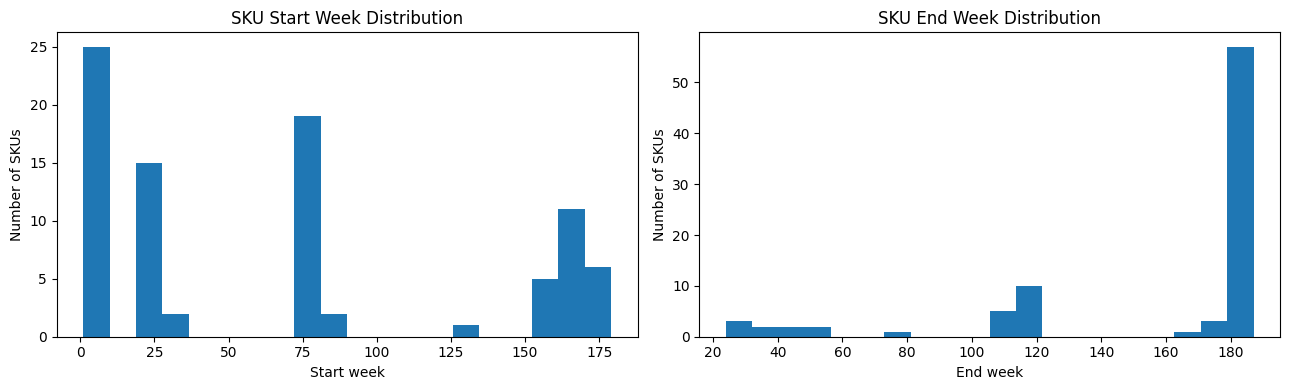

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(metadata["start"].dropna(), bins=20)
axes[0].set_title("SKU Start Week Distribution")
axes[0].set_xlabel("Start week")
axes[0].set_ylabel("Number of SKUs")

axes[1].hist(metadata["end"].dropna(), bins=20)
axes[1].set_title("SKU End Week Distribution")
axes[1].set_xlabel("End week")
axes[1].set_ylabel("Number of SKUs")

plt.tight_layout()
plt.show()


## 9. Missing-value analysis

In [18]:
missing_by_sku = demand_wide.drop(columns="Week").isna().sum()
missing_fraction_by_sku = demand_wide.drop(columns="Week").isna().mean()

missing_summary = pd.DataFrame({
    "missing_count": missing_by_sku,
    "missing_fraction": missing_fraction_by_sku,
}).sort_values("missing_fraction", ascending=False)

display(missing_summary.head(20))

print("Total missing demand cells:", int(demand_wide.drop(columns="Week").isna().sum().sum()))


,missing_count,missing_fraction
SKU.I.5,178,0.952
SKU.G.5,178,0.952
SKU.F.5,173,0.925
SKU.N.5,173,0.925
SKU.H.5,173,0.925
SKU.E.5,170,0.909
SKU.Q.5,165,0.882
SKU.S.5,165,0.882
SKU.L.5,165,0.882
SKU.X.5,165,0.882


Total missing demand cells: 8361


### Missingness versus lifecycle metadata

A key question is whether missing values simply represent periods before a SKU was introduced or after it was discontinued.

For each SKU, compare:

- metadata active interval: `[start, end]`
- observed/non-missing demand interval
- missing values inside the metadata-defined active interval


In [19]:
demand_by_sku = demand_wide.set_index("Week")

lifecycle_checks = []

for _, row in metadata.iterrows():
    sku = row["sku"]

    # Try the exact metadata identifier first, then the canonical identifier.
    if sku in demand_by_sku.columns:
        demand_col = sku
    else:
        matches = [
            col for col in demand_by_sku.columns
            if canonical_sku_for_comparison(col) == canonical_sku_for_comparison(sku)
        ]
        demand_col = matches[0] if len(matches) == 1 else None

    if demand_col is None:
        lifecycle_checks.append({
            "sku": sku,
            "demand_column_found": False,
            "missing_inside_active_interval": np.nan,
            "nonmissing_inside_active_interval": np.nan,
        })
        continue

    active = demand_by_sku.loc[
        (demand_by_sku.index >= row["start"]) &
        (demand_by_sku.index <= row["end"]),
        demand_col
    ]

    lifecycle_checks.append({
        "sku": sku,
        "demand_column_found": True,
        "missing_inside_active_interval": int(active.isna().sum()),
        "nonmissing_inside_active_interval": int(active.notna().sum()),
    })

lifecycle_check_df = pd.DataFrame(lifecycle_checks)

display(
    lifecycle_check_df
    .sort_values("missing_inside_active_interval", ascending=False)
    .head(20)
)

print(
    "SKUs with missing values inside metadata-defined active interval:",
    int((lifecycle_check_df["missing_inside_active_interval"] > 0).sum())
)


,sku,demand_column_found,missing_inside_active_interval,nonmissing_inside_active_interval
0,SKU-A-2,True,0,110
1,SKU-B-2,True,0,110
2,SKU-C-1,True,0,45
3,SKU-C-2,True,0,116
4,SKU-F-1,True,0,45
5,SKU-F-2,True,0,116
6,SKU-H-2,True,0,116
7,SKU-I-2,True,0,108
8,SKU-J-2,True,0,111
9,SKU-K-2,True,0,116


SKUs with missing values inside metadata-defined active interval: 0


## 10. Demand-value checks

In [20]:
demand_values = demand_wide.drop(columns="Week").apply(
    pd.to_numeric, errors="coerce"
)

negative_count = int((demand_values < 0).sum().sum())
zero_count = int((demand_values == 0).sum().sum())
positive_count = int((demand_values > 0).sum().sum())

print("Negative demand observations:", negative_count)
print("Zero demand observations:", zero_count)
print("Positive demand observations:", positive_count)

print("\nOverall demand statistics:")
display(demand_values.stack().describe())


Negative demand observations: 0
Zero demand observations: 300
Positive demand observations: 7421

Overall demand statistics:


count     7,721.000
mean     41,684.729
std      55,551.798
min           0.000
25%       5,254.000
50%      21,226.000
75%      55,415.000
max     664,203.000
dtype: float64

## 11. Demand statistics by SKU

In [21]:
sku_stats = pd.DataFrame({
    "count": demand_values.count(),
    "missing": demand_values.isna().sum(),
    "mean": demand_values.mean(),
    "std": demand_values.std(),
    "min": demand_values.min(),
    "median": demand_values.median(),
    "max": demand_values.max(),
})

sku_stats["missing_fraction"] = sku_stats["missing"] / len(demand_values)

display(
    sku_stats.sort_values("mean", ascending=False).head(20)
)


,count,missing,mean,std,min,median,max,missing_fraction
SKU.C.4,113,74,"206,662.265","121,256.478",955.000,"202,405.000","664,203.000",0.396
SKU.F.4,109,78,"140,734.128","76,760.123","5,191.000","137,500.000","484,235.000",0.417
SKU.C.2,116,71,"122,804.362","92,860.361","1,751.000","91,719.500","397,771.000",0.380
SKU.P.4,61,126,"105,322.623","81,287.116",0.000,"88,376.000","365,605.000",0.674
SKU.Y.5,25,162,"91,929.840","63,755.618","1,592.000","76,433.000","234,076.000",0.866
SKU.B.2,110,77,"86,342.255","73,981.399",605.000,"64,093.000","317,834.000",0.412
SKU.H.4,109,78,"85,770.688","51,668.213","4,140.000","78,487.000","359,935.000",0.417
SKU.Q.4,114,73,"82,934.035","59,027.676",159.000,"70,326.000","238,264.000",0.390
SKU.H.2,116,71,"79,945.086","61,968.760","1,433.000","59,928.000","242,357.000",0.380
SKU.K.3,168,19,"77,992.595","75,746.344",0.000,"69,172.000","326,481.000",0.102


## 12. Representative demand trajectories

In [22]:
# Select representative SKUs by lifecycle length:
# shortest, median-ish, and longest.

ordered = metadata.sort_values("lifetime_weeks").reset_index(drop=True)

candidate_indices = sorted(set([
    0,
    len(ordered) // 2,
    len(ordered) - 1,
]))

representative_skus = ordered.loc[candidate_indices, "sku"].tolist()
representative_skus


['SKU-G-5', 'SKU-I-4', 'SKU-Q-3']

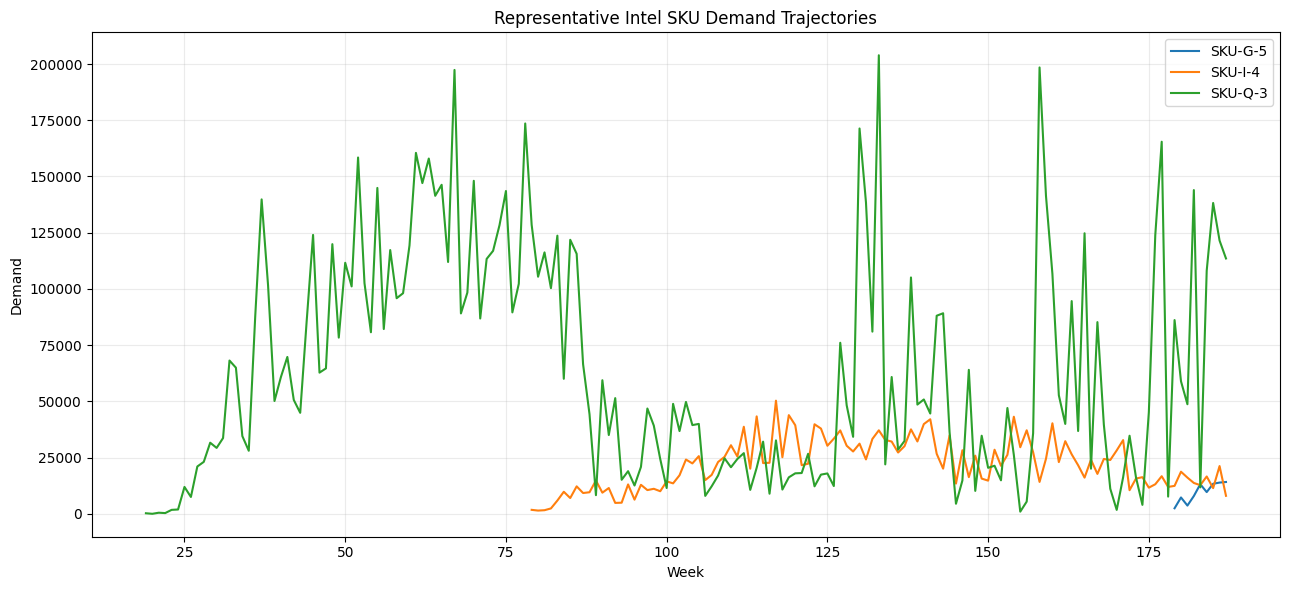

In [23]:
fig, ax = plt.subplots(figsize=(13, 6))

for sku in representative_skus:
    matches = [
        col for col in demand_by_sku.columns
        if canonical_sku_for_comparison(col) == canonical_sku_for_comparison(sku)
    ]
    if not matches:
        continue

    col = matches[0]
    ax.plot(
        demand_by_sku.index,
        demand_by_sku[col],
        label=sku,
        linewidth=1.5
    )

ax.set_title("Representative Intel SKU Demand Trajectories")
ax.set_xlabel("Week")
ax.set_ylabel("Demand")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 13. Lifecycle visualization

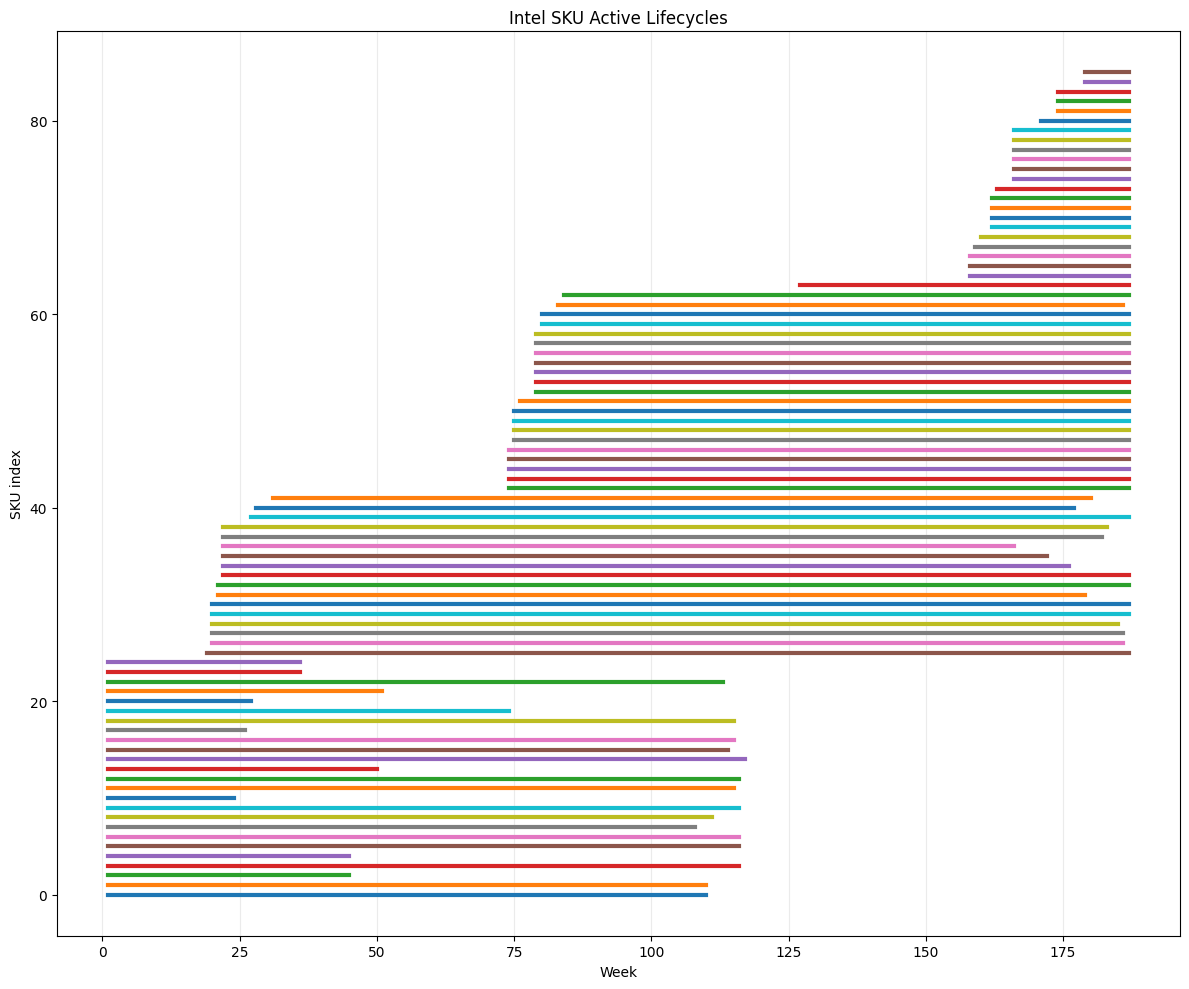

In [34]:
lifecycle_plot = metadata.sort_values("start").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

for i, row in lifecycle_plot.iterrows():
    ax.plot(
        [row["start"], row["end"]],
        [i, i],
        linewidth=3
    )

ax.set_title("Intel SKU Active Lifecycles")
ax.set_xlabel("Week")
ax.set_ylabel("SKU index")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


# 14. Validate the per-distribution-center demand representation.

In [ ]:
key_cols = ["Distribution Center", "SKU", "Week"]

# 1. Check duplicate observations for the same center, SKU and week.
duplicate_mask = source.duplicated(subset=key_cols, keep=False)

print("Duplicate center-SKU-week rows:", int(duplicate_mask.sum()))

if duplicate_mask.any():
    display(
        source.loc[duplicate_mask]
        .sort_values(key_cols)
        .head(20)
    )

# 2. Check missing demand values.
print("\nMissing values:")
display(
    source[
        ["Customer Orders", "Forecasted Demand"]
    ].isna().sum()
)

# 3. Check negative values in the two demand-related columns.
print("\nNegative values:")
display(
    (source[["Customer Orders", "Forecasted Demand"]] < 0).sum()
)

# 4. Inspect distribution-center coverage.
print("\nRows per distribution center:")
display(source.groupby("Distribution Center").size().rename("row_count"))

print("\nDistinct SKUs per distribution center:")
display(
    source.groupby("Distribution Center")["SKU"]
    .nunique()
    .rename("sku_count")
)

print("\nObserved weeks per distribution center:")
display(
    source.groupby("Distribution Center")["Week"]
    .agg(["min", "max", "nunique"])
)

# 5. Inspect coverage for each center-SKU pair.
center_sku_coverage = (
    source.groupby(["Distribution Center", "SKU"])["Week"]
    .agg(first_week="min", last_week="max", observed_weeks="nunique")
    .reset_index()
)

center_sku_coverage["expected_weeks_in_span"] = (
    center_sku_coverage["last_week"]
    - center_sku_coverage["first_week"]
    + 1
)

center_sku_coverage["has_internal_week_gaps"] = (
    center_sku_coverage["observed_weeks"]
    != center_sku_coverage["expected_weeks_in_span"]
)

print(
    "\nCenter-SKU pairs with missing weeks inside their observed span:",
    int(center_sku_coverage["has_internal_week_gaps"].sum()),
)

display(
    center_sku_coverage[
        center_sku_coverage["has_internal_week_gaps"]
    ].head(20)
)

Duplicate center-SKU-week rows: 0

Missing values:


Customer Orders      0
Forecasted Demand    0
dtype: int64


Negative values:


Customer Orders      0
Forecasted Demand    0
dtype: int64


Rows per distribution center:


...

Distribution Center
ALPHA      80
BETA       60
DELTA      84
EPSILON    84
GAMMA      86
Name: sku_count, dtype: int64


Observed weeks per distribution center:


,min,max,nunique
Distribution Center,,,
ALPHA,1,187,186
BETA,1,187,185
DELTA,1,187,187
EPSILON,1,187,187
GAMMA,1,187,187



Center-SKU pairs with missing weeks inside their observed span: 321


,Distribution Center,SKU,first_week,last_week,observed_weeks,expected_weeks_in_span,has_internal_week_gaps
0,ALPHA,SKU-A-2,1,101,89,101,True
1,ALPHA,SKU-A-3,23,130,92,108,True
2,ALPHA,SKU-A-4,77,186,104,110,True
3,ALPHA,SKU-A-5,163,187,21,25,True
5,ALPHA,SKU-B-2,1,103,92,103,True
6,ALPHA,SKU-B-3,23,147,111,125,True
7,ALPHA,SKU-B-4,77,187,107,111,True
8,ALPHA,SKU-B-5,165,187,15,23,True
9,ALPHA,SKU-C-1,1,37,36,37,True
10,ALPHA,SKU-C-2,1,116,109,116,True


The above code block shows that, although customer orders for a specific product may be non-zero when aggregated across distribution centers, some distribution centers may have no recorded orders for that product during certain weeks. This is possible when examining demand at the individual distribution-center level.

## 15. Preliminary findings

1. **Dataset dimensions**
   - 86 SKUs.
   - 187 weekly time points.
   - The original source contains 26,114 distribution-center-level records.

2. **Static product metadata**
   - The original source contains `Product Offering`, `Generation`, and `ASP Group`.
   - These three attributes are constant within each SKU.
   - They should be retained in the processed SKU metadata table for the cold-start experiment.

3. **Preprocessing implication**
   - Processed metadata should contain:
     `sku`, `start_week`, `end_week`, `product_offering`, `generation`, `asp_group`.
   - Processed demand should remain model-independent; experiment-specific normalization should be applied later.
